### RANDOM FOREST

In [ ]:
# DATA

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix)

# Same student dataset
data = {
    "study_hours": [2,4,6,1,8,3,7,5,9,2,
                    6,4,8,1,5,3,7,9,2,6,
                    4,8,1,5,3,7,9,2,6,4],
    "attendance":  [60,75,85,50,95,65,90,80,98,55,
                    82,70,93,48,78,62,88,96,52,83,
                    72,91,45,76,60,87,94,54,81,68],
    "prev_score":  [45,62,75,38,88,55,82,70,91,42,
                    73,60,85,35,68,50,80,90,40,74,
                    58,86,32,66,48,79,92,44,72,62],
    "passed":      [0,1,1,0,1,0,1,1,1,0,
                    1,1,1,0,1,0,1,1,0,1,
                    1,1,0,1,0,1,1,0,1,1]
}

df = pd.DataFrame(data)
X = df[["study_hours", "attendance", "prev_score"]]
y = df["passed"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [3]:
# Train Random Forest

In [4]:
rf_model=RandomForestClassifier(
    n_estimators=100,
    max_depth=3,
    random_state=42)
rf_model.fit(X_train,y_train)
print("Random Forest trained with 100 trees!")

Random Forest trained with 100 trees!


In [6]:
# Evaluate

In [9]:
y_pred = rf_model.predict(X_test)
print(f"Accuracy:{accuracy_score(y_test,y_pred):.2%}")
print("CLASSIFICATION REPORT!")
print(classification_report(y_test, y_pred,
      target_names=["Fail", "Pass"]))

Accuracy:100.00%
CLASSIFICATION REPORT!
              precision    recall  f1-score   support

        Fail       1.00      1.00      1.00         3
        Pass       1.00      1.00      1.00         3

    accuracy                           1.00         6
   macro avg       1.00      1.00      1.00         6
weighted avg       1.00      1.00      1.00         6



In [10]:
#Feature Importance

       Feature  Importance
0  study_hours        0.36
1   attendance        0.36
2   prev_score        0.28


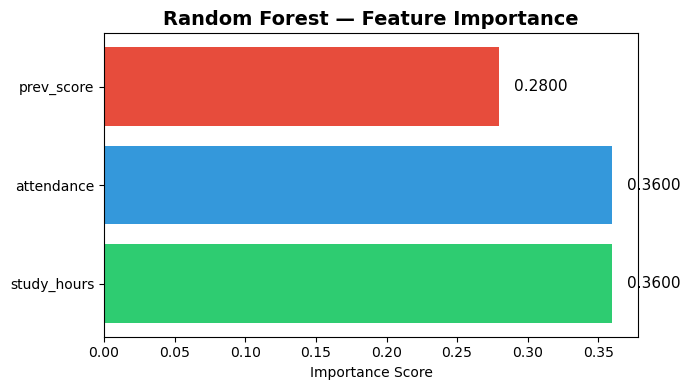

In [14]:
importance = pd.DataFrame({
    "Feature":    X.columns,
    "Importance": rf_model.feature_importances_
}).sort_values("Importance", ascending=False)
print(importance)
plt.figure(figsize=(7, 4))
plt.barh(importance["Feature"], importance["Importance"],
         color=["#2ECC71", "#3498DB", "#E74C3C"])
plt.title("Random Forest — Feature Importance",
          fontsize=14, fontweight="bold")
plt.xlabel("Importance Score")
for i, val in enumerate(importance["Importance"]):
    plt.text(val + 0.01, i, f"{val:.4f}",
             va="center", fontsize=11)
plt.tight_layout()
plt.show()

In [15]:
#Compare number of trees

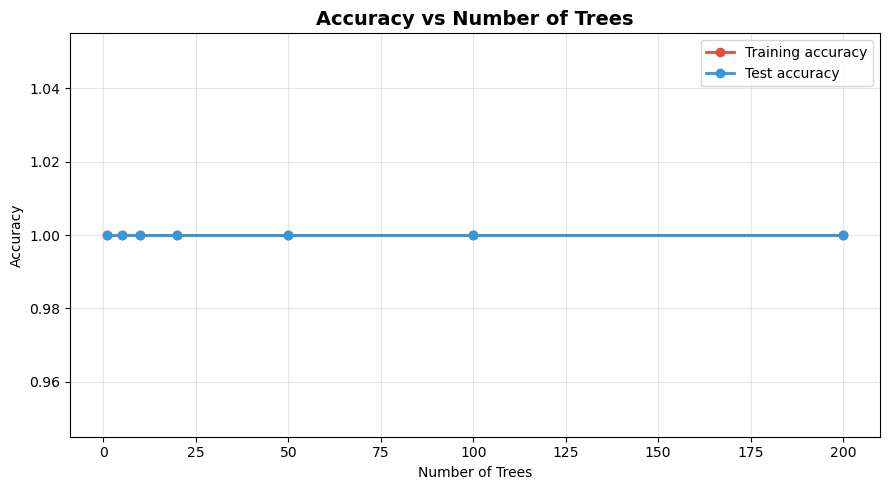

In [23]:
# How does accuracy change as we add more trees?
n_trees = [1, 5, 10, 20, 50, 100, 200]
test_scores = []
train_scores = []
for n in n_trees:
    m = RandomForestClassifier(n_estimators=n, random_state=42)
    m.fit(X_train, y_train)
    train_scores.append(accuracy_score(y_train, m.predict(X_train)))
    test_scores.append(accuracy_score(y_test, m.predict(X_test)))

plt.figure(figsize=(9, 5))
plt.plot(n_trees, train_scores, marker="o",
         color="#E74C3C", label="Training accuracy", linewidth=2)
plt.plot(n_trees, test_scores, marker="o",
         color="#3498DB", label="Test accuracy", linewidth=2)
plt.title("Accuracy vs Number of Trees",
          fontsize=14, fontweight="bold")
plt.xlabel("Number of Trees")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [39]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

models = {
    "Logistic Regression": LogisticRegression(random_state=42),
    "Decision Tree":       DecisionTreeClassifier(max_depth=3,
                                                  random_state=42),
    "Random Forest":       RandomForestClassifier(n_estimators=100,
                                                  random_state=42)
}

results = []
for name, model in models.items():
    # Cross validation
    cv_scores = cross_val_score(model, X, y, cv=5, scoring="accuracy")

    # Train/test scores for overfitting check
    model.fit(X_train, y_train)
    train_acc = accuracy_score(y_train, model.predict(X_train))
    test_acc  = accuracy_score(y_test, model.predict(X_test))

    results.append({
        "Model":      name,
        "CV Mean":    cv_scores.mean().round(4),
        "CV Std":     cv_scores.std().round(4),
        "Train Acc":  train_acc,
        "Test Acc":   test_acc,
        "Overfit Gap": (train_acc - test_acc)
    })

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

              Model  CV Mean  CV Std  Train Acc  Test Acc  Overfit Gap
Logistic Regression      1.0     0.0        1.0       1.0          0.0
      Decision Tree      1.0     0.0        1.0       1.0          0.0
      Random Forest      1.0     0.0        1.0       1.0          0.0


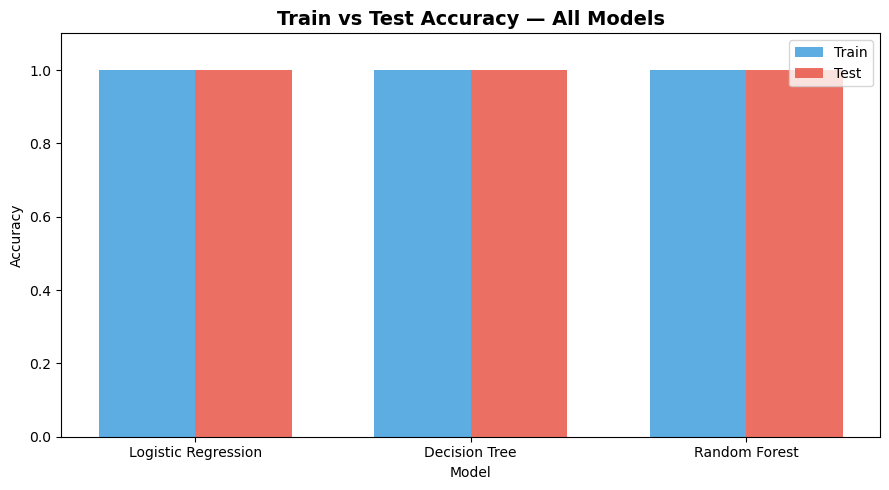

In [40]:
plt.figure(figsize=(9, 5))
x = np.arange(len(results_df))
width = 0.35

bars1 = plt.bar(x - width/2, results_df["Train Acc"],
                width, label="Train", color="#3498DB", alpha=0.8)
bars2 = plt.bar(x + width/2, results_df["Test Acc"],
                width, label="Test", color="#E74C3C", alpha=0.8)

plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.title("Train vs Test Accuracy — All Models",
          fontsize=14, fontweight="bold")
plt.xticks(x, results_df["Model"])
plt.legend()
plt.ylim(0, 1.1)
plt.tight_layout()
plt.show()